In [1]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit

In [2]:
import sklearn
from sklearn.decomposition import PCA

In [3]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [4]:
def S11_resonator(freq, fc, ke, ki, a0, a1, Poff, ed):
    numer = 1j*(freq-fc)+(ke-ki)/2
    denom = 1j*(freq-fc)-(ke+ki)/2
    model = (numer/denom * (a0+a1*(freq-freq[0])) * np.exp(1j*(-Poff-ed*2*np.pi*freq))).conj()
    return model

In [6]:
header = "C:/Users/qipe/Documents/K_Sunada/result/CDK184/"
current_tx = "/2025-08-11/2025-08-11T111743_5d03acf0-cw_JPA_current_vs_freq"
dd_tx = datadict_from_hdf5(header + current_tx +"/data")

x_tx = np.unique(dd_tx['current']['values'])
y_tx = np.unique(dd_tx['frequency']['values'])
z_tx = dd_tx['s11']['values']/dd_tx['s11']['values'][-1]
z_tx.shape

current_rx = "/2025-08-11/2025-08-11T124605_b5289025-cw_JPA_current_vs_freq"
dd_rx = datadict_from_hdf5(header + current_rx +"/data")

x_rx = np.unique(dd_rx['current']['values'])
y_rx = np.unique(dd_rx['frequency']['values'])
z_rx = dd_rx['s11']['values']/dd_rx['s11']['values'][-1]
z_rx.shape

current_txrx = "/2025-08-11/2025-08-11T114023_87744f8d-cw_JPA_current_vs_freq"
dd_txrx = datadict_from_hdf5(header + current_txrx +"/data")

x_txrx = np.unique(dd_txrx['current']['values'])
y_txrx = np.unique(dd_txrx['frequency']['values'])
z_txrx = dd_txrx['s11']['values']/dd_txrx['s11']['values'][-1]
z_txrx.shape

(21, 401)

In [42]:
par_ini = {'fc':8.5,'ke':0.1,'ki':0.0002,'a0':0.96,'a1':0,'Poff':0.26,'ed':0,}
par_min = {'fc':0,'ke':0,'ki':0,'a0':0,'a1':- np.inf,'Poff':- np.pi,'ed':- np.inf,}
par_max = {'fc':np.inf,'ke':np.inf,'ki':np.inf,'a0':np.inf,'a1':np.inf,'Poff':np.pi,'ed':np.inf,}
par_vary = {'fc':True,'ke':True,'ki':True,'a0':True,'a1':False,'Poff':True,'ed':True,}
model = lmfit.Model(S11_resonator)

params = model.make_params()
for name in model.param_names:
    params[name].set(value = par_ini[name],min = par_min[name],max = par_max[name],vary = par_vary[name])

Fitting id = 0 ...
Fitting id = 1 ...
Fitting id = 2 ...
Fitting id = 3 ...
Fitting id = 4 ...
Fitting id = 5 ...
Fitting id = 6 ...
Fitting id = 7 ...
Fitting id = 8 ...
Fitting id = 9 ...
Fitting id = 10 ...
Fitting id = 11 ...
Fitting id = 12 ...
Fitting id = 13 ...
Fitting id = 14 ...
Fitting id = 15 ...
Fitting id = 16 ...
Fitting id = 17 ...


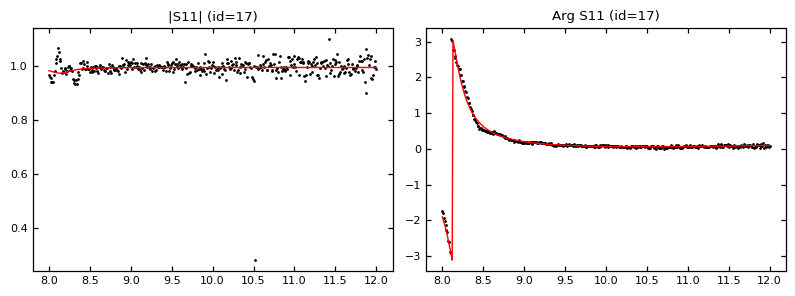

取得した fc 一覧:
[10.89152169 10.88851343 10.87413246 10.85078467 10.81684948 10.77019975
 10.71218952 10.64059193 10.55209679 10.44240115 10.31655284 10.17034505
  9.98544294  9.76037697  9.4901509   9.15019411  8.71955243  8.13805752]


In [36]:
ids = range(len(x_tx))  # 例：0〜20 が使える場合

fc_list = []
fit_results = {}
plot_id =17

for idx in ids[0:-3]:
    print(f"Fitting id = {idx} ...")

    s11 = z_tx[idx]
    
    # --- モデルとパラメータ設定 ---
    model = lmfit.Model(S11_resonator)
    params = model.make_params()
    for name in model.param_names:
        params[name].set(
            value = par_ini[name],
            min   = par_min[name],
            max   = par_max[name],
            vary  = par_vary[name]
        )
    
    # --- フィッティング ---
    res = model.fit(data=s11, params=params, freq=y_tx)
    
    # --- 保存 ---
    fc_list.append(res.best_values['fc'])
    fit_results[idx] = res  # 必要なら全結果保存
    
    # --- 途中で簡易プロットしたい場合 ---
    if idx == plot_id:  # 5 ステップごとに確認
        fig, ax = plt.subplots(1,2, figsize=(8,3))
        ax[0].plot(y_tx, np.abs(s11), '.', color='k')
        ax[0].plot(y_tx, np.abs(res.best_fit), '-', color='red')
        ax[0].set_title(f"|S11| (id={idx})")
        
        ax[1].plot(y_tx, np.angle(s11), '.', color='k')
        ax[1].plot(y_tx, np.angle(res.best_fit), '-', color='red')
        ax[1].set_title(f"Arg S11 (id={idx})")
        
        plt.tight_layout()
        plt.show()


fc_array_tx = np.array(fc_list)

print("取得した fc 一覧:")
print(fc_array_tx)


In [47]:
par_ini = {'fc':10,'ke':0.1,'ki':0.0002,'a0':0.96,'a1':0,'Poff':0.26,'ed':0,}
par_ini1 = {'fc':8,'ke':0.1,'ki':0.0002,'a0':0.96,'a1':0,'Poff':0.26,'ed':0,}
par_min = {'fc':0,'ke':0,'ki':0,'a0':0,'a1':- np.inf,'Poff':- np.pi,'ed':- np.inf,}
par_max = {'fc':np.inf,'ke':np.inf,'ki':np.inf,'a0':np.inf,'a1':np.inf,'Poff':np.pi,'ed':np.inf,}
par_vary = {'fc':True,'ke':True,'ki':True,'a0':True,'a1':False,'Poff':True,'ed':True,}
model = lmfit.Model(S11_resonator)

params = model.make_params()
for name in model.param_names:
    params[name].set(value = par_ini[name],min = par_min[name],max = par_max[name],vary = par_vary[name])

Fitting id = 0 ...


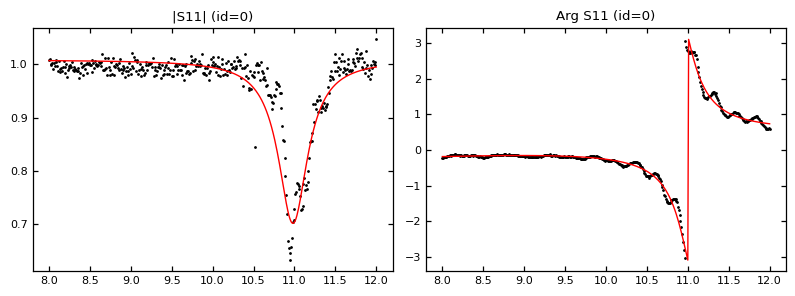

Fitting id = 1 ...
Fitting id = 2 ...
Fitting id = 3 ...
Fitting id = 4 ...
Fitting id = 5 ...
Fitting id = 6 ...
Fitting id = 7 ...
Fitting id = 8 ...
Fitting id = 9 ...
Fitting id = 10 ...
Fitting id = 11 ...
Fitting id = 12 ...
Fitting id = 13 ...
Fitting id = 14 ...
Fitting id = 15 ...
Fitting id = 16 ...
Fitting id = 17 ...
取得した fc 一覧:
[10.98155513 10.97568038 10.95884032 10.92968863 10.88864389 10.83555794
 10.76730419 10.68599401 10.58640725 10.46719595 10.33154198 10.15709519
  9.95011531  9.70779767  9.39946239  9.01822884  8.54682526  7.95394862]


In [48]:
ids = range(len(x_rx))  # 例：0〜20 が使える場合

fc_list = []
fit_results = {}
plot_id =0

for idx in ids[0:-3]:
    print(f"Fitting id = {idx} ...")

    s11 = z_rx[idx]
    
    # --- モデルとパラメータ設定 ---
    model = lmfit.Model(S11_resonator)
    params = model.make_params()
    if idx < 10:
        for name in model.param_names:
            params[name].set(
                value = par_ini[name],
                min   = par_min[name],
                max   = par_max[name],
                vary  = par_vary[name]
            )
    else:
        for name in model.param_names:
            params[name].set(
                value = par_ini1[name],
                min   = par_min[name],
                max   = par_max[name],
                vary  = par_vary[name]
            )
    
    # --- フィッティング ---
    res = model.fit(data=s11, params=params, freq=y_rx)
    
    # --- 保存 ---
    fc_list.append(res.best_values['fc'])
    fit_results[idx] = res  # 必要なら全結果保存
    
    # --- 途中で簡易プロットしたい場合 ---
    if idx == plot_id:  # 5 ステップごとに確認
        fig, ax = plt.subplots(1,2, figsize=(8,3))
        ax[0].plot(y_rx, np.abs(s11), '.', color='k')
        ax[0].plot(y_rx, np.abs(res.best_fit), '-', color='red')
        ax[0].set_title(f"|S11| (id={idx})")
        
        ax[1].plot(y_rx, np.angle(s11), '.', color='k')
        ax[1].plot(y_rx, np.angle(res.best_fit), '-', color='red')
        ax[1].set_title(f"Arg S11 (id={idx})")
        
        plt.tight_layout()
        plt.show()


fc_array_rx = np.array(fc_list)

print("取得した fc 一覧:")
print(fc_array_rx)

In [53]:
par_ini = {'fc':10,'ke':0.1,'ki':0.0002,'a0':0.96,'a1':0,'Poff':0.26,'ed':0,}
par_ini1 = {'fc':7.5,'ke':0.1,'ki':0.0002,'a0':0.96,'a1':0,'Poff':0.26,'ed':0,}
par_min = {'fc':0,'ke':0,'ki':0,'a0':0,'a1':- np.inf,'Poff':- np.pi,'ed':- np.inf,}
par_max = {'fc':np.inf,'ke':np.inf,'ki':np.inf,'a0':np.inf,'a1':np.inf,'Poff':np.pi,'ed':np.inf,}
par_vary = {'fc':True,'ke':True,'ki':True,'a0':True,'a1':False,'Poff':True,'ed':True,}
model = lmfit.Model(S11_resonator)

params = model.make_params()
for name in model.param_names:
    params[name].set(value = par_ini[name],min = par_min[name],max = par_max[name],vary = par_vary[name])

In [56]:
ids = range(len(x_txrx))  # 例：0〜20 が使える場合

fc_list = []
fit_results = {}
plot_id =18

for idx in ids[0:-3]:
    print(f"Fitting id = {idx} ...")

    s11 = z_txrx[idx]
    
    # --- モデルとパラメータ設定 ---
    model = lmfit.Model(S11_resonator)
    params = model.make_params()
    if idx < 10:
        for name in model.param_names:
            params[name].set(
                value = par_ini[name],
                min   = par_min[name],
                max   = par_max[name],
                vary  = par_vary[name]
            )
    else:
        for name in model.param_names:
            params[name].set(
                value = par_ini1[name],
                min   = par_min[name],
                max   = par_max[name],
                vary  = par_vary[name]
            )
    
    # --- フィッティング ---
    res = model.fit(data=s11, params=params, freq=y_txrx)
    
    # --- 保存 ---
    fc_list.append(res.best_values['fc'])
    fit_results[idx] = res  # 必要なら全結果保存
    
    # --- 途中で簡易プロットしたい場合 ---
    if idx == plot_id:  # 5 ステップごとに確認
        fig, ax = plt.subplots(1,2, figsize=(8,3))
        ax[0].plot(y_txrx, np.abs(s11), '.', color='k')
        ax[0].plot(y_txrx, np.abs(res.best_fit), '-', color='red')
        ax[0].set_title(f"|S11| (id={idx})")
        
        ax[1].plot(y_txrx, np.angle(s11), '.', color='k')
        ax[1].plot(y_txrx, np.angle(res.best_fit), '-', color='red')
        ax[1].set_title(f"Arg S11 (id={idx})")
        
        plt.tight_layout()
        plt.show()


fc_array_txrx = np.array(fc_list)

print("取得した fc 一覧:")
print(fc_array_txrx)


Fitting id = 0 ...
Fitting id = 1 ...
Fitting id = 2 ...
Fitting id = 3 ...
Fitting id = 4 ...
Fitting id = 5 ...
Fitting id = 6 ...
Fitting id = 7 ...
Fitting id = 8 ...
Fitting id = 9 ...
Fitting id = 10 ...
Fitting id = 11 ...
Fitting id = 12 ...
Fitting id = 13 ...
Fitting id = 14 ...
Fitting id = 15 ...
Fitting id = 16 ...
Fitting id = 17 ...
取得した fc 一覧:
[9.89349197 9.88840688 9.87365389 9.84822814 9.81104716 9.76313283
 9.7027107  9.62939577 9.5426956  9.43979343 9.31556661 9.16215578
 8.98322172 8.76582649 8.50573672 8.17178705 7.74448469 7.18516546]


C:\Users\qipe\AppData\Local\Temp\ipykernel_36064\1948488957.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('viridis')


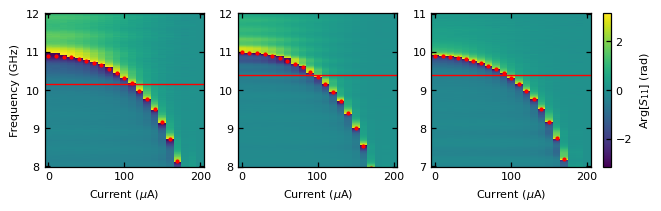

In [64]:
fig, axes = plt.subplots(1,3, figsize=(6.5,2), constrained_layout=True)
cm = plt.cm.get_cmap('viridis')
plt.rcParams.update({
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.width': 0.9,
    'ytick.major.width': 0.9,
    'font.size': 8,
    'axes.linewidth': 0.9,
    'xtick.top': True,
    'xtick.bottom': True,
    'ytick.left': True,
    'ytick.right': True,
    'lines.linewidth': 1,
    'lines.markersize': 2
})
angle_tx   = np.angle(z_tx)
angle_rx   = np.angle(z_rx)
angle_txrx = np.angle(z_txrx)

vmin = min(angle_tx.min(), angle_rx.min(), angle_txrx.min())
vmax = max(angle_tx.max(), angle_rx.max(), angle_txrx.max())

# --- 1. TX ---------------------------------------------------------------
ax = axes[0]
img0 = ax.pcolormesh(
    x_tx, y_tx, angle_tx.reshape(21, 401).T,
    vmin=vmin, vmax=vmax, cmap=cm, shading='auto'
)
ax.set_xlabel(r"Current ($\mu$A)")
ax.set_ylabel("Frequency (GHz)")
ax.plot(x_tx[0:len(fc_array_tx)], fc_array_tx, 'o',color='red')
ax.axhline(y=10.149, color="red")

# --- 2. RX ---------------------------------------------------------------
ax = axes[1]
img1 = ax.pcolormesh(
    x_rx, y_rx, angle_rx.reshape(21, 401).T,
    vmin=vmin, vmax=vmax, cmap=cm, shading='auto'
)
ax.set_xlabel(r"Current ($\mu$A)")
ax.plot(x_rx[0:len(fc_array_rx)], fc_array_rx, 'o',color='red')
ax.set_ylim(8, 12)
ax.axhline(y=10.389, color="red")

# --- 3. TX-RX ------------------------------------------------------------
ax = axes[2]
img2 = ax.pcolormesh(
    x_txrx, y_txrx, angle_txrx.reshape(21, 401).T,
    vmin=vmin, vmax=vmax, cmap=cm, shading='auto'
)
ax.set_xlabel(r"Current ($\mu$A)")
ax.plot(x_txrx[0:len(fc_array_txrx)], fc_array_txrx, 'o',color='red')
ax.axhline(y=9.38, color="red")

# --- 共通カラーバーを1つだけ --------------------------------------------
cbar = fig.colorbar(img2, ax=axes, label="Arg[$S_{11}$] (rad)", pad=0.01)
# ax=axes によって全 axis をまたいだカラーバーになる
# plt.savefig("mas_figs/JPA_spectrum.pdf",  bbox_inches="tight")
plt.show()

pump power

In [65]:
pump_tx ="/2025-08-11/2025-08-11T112701_a9d0f48b-cw_JPA_gain_amp_currents"
dd_tx = datadict_from_hdf5(header + pump_tx +"/data")
dd_tx

pump_rx ="/2025-08-11/2025-08-11T131245_6f4ad7b4-cw_JPA_gain_amp_currents"
dd_rx = datadict_from_hdf5(header + pump_rx +"/data")
dd_rx

pump_txrx ="/2025-08-11/2025-08-11T115103_052cc735-cw_JPA_gain_amp_currents"
dd_txrx = datadict_from_hdf5(header + pump_txrx +"/data")
dd_txrx

Gain: (176, 201)
  ⌙ frequency (GHz): (176, 201)
  ⌙ amplitude (V): (176,)
  ⌙ current (A): (176,)
s11: (176, 201)
  ⌙ frequency (GHz): (176, 201)
  ⌙ amplitude (V): (176,)
  ⌙ current (A): (176,)
s11_per_base: (176, 201)
  ⌙ frequency (GHz): (176, 201)
  ⌙ amplitude (V): (176,)
  ⌙ current (A): (176,)

C:\Users\qipe\AppData\Local\Temp\ipykernel_36064\1596249108.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('viridis')


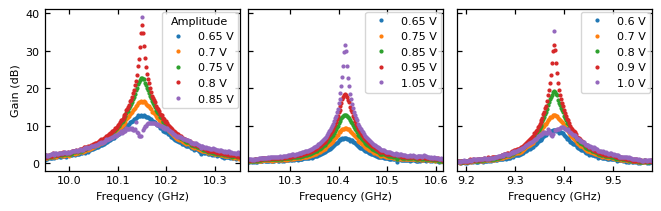

In [132]:
dd = dd_tx
curr_all = dd['current']['values']   # (176,)
amp_all  = dd['amplitude']['values'] # (176,)
freq_all = dd['frequency']['values'] # (176, 201)
gain_all = dd['Gain']['values']      # (176, 201)
target_current = 112e-6
idx = np.where(np.isclose(curr_all, target_current))[0]
freq_i_tx = freq_all[idx]  *1e-9     # (Na, Nf)
gain_i_tx = gain_all[idx]        # (Na, Nf)
amps_i_tx = amp_all[idx]         # (Na,)
idxs_tx=[1, 2, 3, 4, 5]

dd = dd_rx
curr_all = dd['current']['values']   # (176,)
amp_all  = dd['amplitude']['values'] # (176,)
freq_all = dd['frequency']['values'] # (176, 201)
gain_all = dd['Gain']['values']      # (176, 201)
target_current =92e-6
idx = np.where(np.isclose(curr_all, target_current))[0]
freq_i_rx = freq_all[idx]  *1e-9     # (Na, Nf)
gain_i_rx = gain_all[idx]        # (Na, Nf)
amps_i_rx = amp_all[idx]         # (Na,)
idxs_rx=[1, 3, 5, 7,  9]

dd = dd_txrx
curr_all = dd['current']['values']   # (176,)
amp_all  = dd['amplitude']['values'] # (176,)
freq_all = dd['frequency']['values'] # (176, 201)
gain_all = dd['Gain']['values']      # (176, 201)
target_current =96e-6
idx = np.where(np.isclose(curr_all, target_current))[0]
freq_i_txrx = freq_all[idx]  *1e-9     # (Na, Nf)
gain_i_txrx = gain_all[idx]        # (Na, Nf)
amps_i_txrx = amp_all[idx]         # (Na,)
idxs_txrx=[0, 2, 4, 6, 8]

fig, axes = plt.subplots(1,3, figsize=(6.5,2), sharey=True, constrained_layout=True)
cm = plt.cm.get_cmap('viridis')
plt.rcParams.update({
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.width': 0.9,
    'ytick.major.width': 0.9,
    'font.size': 8,
    'axes.linewidth': 0.9,
    'xtick.top': True,
    'xtick.bottom': True,
    'ytick.left': True,
    'ytick.right': True,
    'lines.linewidth': 1,
    'lines.markersize': 2
})

ax = axes[0]
for idx in idxs_tx:
    ax.plot(freq_i_tx[idx], gain_i_tx[idx], "o", label=rf"{np.round(amps_i_txrx[idx],2)} V")
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Gain (dB)")
ax.legend(title="Amplitude", loc="upper right", bbox_to_anchor=(1.02, 1.02))
ax.set_xlim(freq_i_tx[idx][0], freq_i_tx[idx][-1])

ax = axes[1]
for idx in idxs_rx:
    ax.plot(freq_i_rx[idx], gain_i_rx[idx], "o", label=rf"{np.round(amps_i_txrx[idx],2)} V")
ax.set_xlabel("Frequency (GHz)")
ax.legend(loc="upper right", bbox_to_anchor=(1.02, 1.02))
ax.set_xlim(freq_i_rx[idx][0], freq_i_rx[idx][-1])

ax = axes[2]
for idx in idxs_txrx:
    ax.plot(freq_i_txrx[idx], gain_i_txrx[idx], "o", label=rf"{np.round(amps_i_txrx[idx],2)} V")
ax.set_xlabel("Frequency (GHz)")
ax.legend(loc="upper right", bbox_to_anchor=(1.02, 1.02))
ax.set_xlim(freq_i_txrx[idx][0], freq_i_txrx[idx][-1])
# plt.savefig("mas_figs/JPA_pump.pdf",  bbox_inches="tight")
plt.show()